# 03 - Modeling

We train, tune, and compare 8 models + a stacking ensemble.

1. Load preprocessed data
2. Baseline model comparison (5-fold CV)
3. Hyperparameter tuning with Optuna (XGBoost + LightGBM)
4. Stacking ensemble
5. Weighted blend
6. Final model analysis & predictions
7. Learning curves
8. Submit predictions

In [1]:
import sys, pickle, os
import importlib.util
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')
os.makedirs('../plots', exist_ok=True)

from sklearn.model_selection import KFold, learning_curve
from sklearn.metrics import mean_squared_error, r2_score
import xgboost as xgb
import lightgbm as lgb

def load_module(name, path):
    spec = importlib.util.spec_from_file_location(name, os.path.abspath(path))
    mod  = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(mod)
    return mod

models_mod = load_module("models", "../src/models.py")

get_baseline_models    = models_mod.get_baseline_models
evaluate_all           = models_mod.evaluate_all
cv_rmse                = models_mod.cv_rmse
tune_xgboost           = models_mod.tune_xgboost
tune_lightgbm          = models_mod.tune_lightgbm
build_stacking_ensemble = models_mod.build_stacking_ensemble
weighted_blend         = models_mod.weighted_blend

plt.rcParams.update({
    'figure.facecolor':'white','axes.facecolor':'#f9f9f9',
    'axes.grid':True,'grid.alpha':0.35,'axes.spines.top':False,'axes.spines.right':False,
    'font.size':11,'axes.titlesize':13,'axes.titleweight':'bold'
})
C = ['#4C6EF5','#F76707','#2F9E44','#E03131','#7950F2','#1098AD','#F59F00','#364FC7']

# Load preprocessed data
with open('../data/processed/pipeline_data.pkl', 'rb') as f:
    data = pickle.load(f)

X_train       = data['X_train']
X_test        = data['X_test']
y             = data['y']
feature_names = data['feature_names']
test_ids      = data['test_ids']

print(f'X_train: {X_train.shape}  y: {y.shape}  X_test: {X_test.shape}')

X_train: (1458, 98)  y: (1458,)  X_test: (1459, 98)


## 1. Baseline Model Comparison

In [2]:
print('Running 5-fold CV for all baseline models...')
results_df = evaluate_all(X_train, y, verbose=True)

Running 5-fold CV for all baseline models...
  Ridge                           RMSE: 0.11657 ± 0.00806
  Lasso                           RMSE: 0.11636 ± 0.00805
  ElasticNet                      RMSE: 0.11628 ± 0.00804
  SVR                             RMSE: 0.11642 ± 0.00803
  Random Forest                   RMSE: 0.13321 ± 0.00787
  Gradient Boosting               RMSE: 0.11901 ± 0.00820
  XGBoost                         RMSE: 0.11592 ± 0.00529


  File "c:\Users\abhim\AppData\Local\Programs\Python\Python310\lib\site-packages\joblib\externals\loky\backend\context.py", line 257, in _count_physical_cores
    cpu_info = subprocess.run(
  File "c:\Users\abhim\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 503, in run
    with Popen(*popenargs, **kwargs) as process:
  File "c:\Users\abhim\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 971, in __init__
    self._execute_child(args, executable, preexec_fn, close_fds,
  File "c:\Users\abhim\AppData\Local\Programs\Python\Python310\lib\subprocess.py", line 1440, in _execute_child
    hp, ht, pid, tid = _winapi.CreateProcess(executable, args,


  LightGBM                        RMSE: 0.12260 ± 0.00658


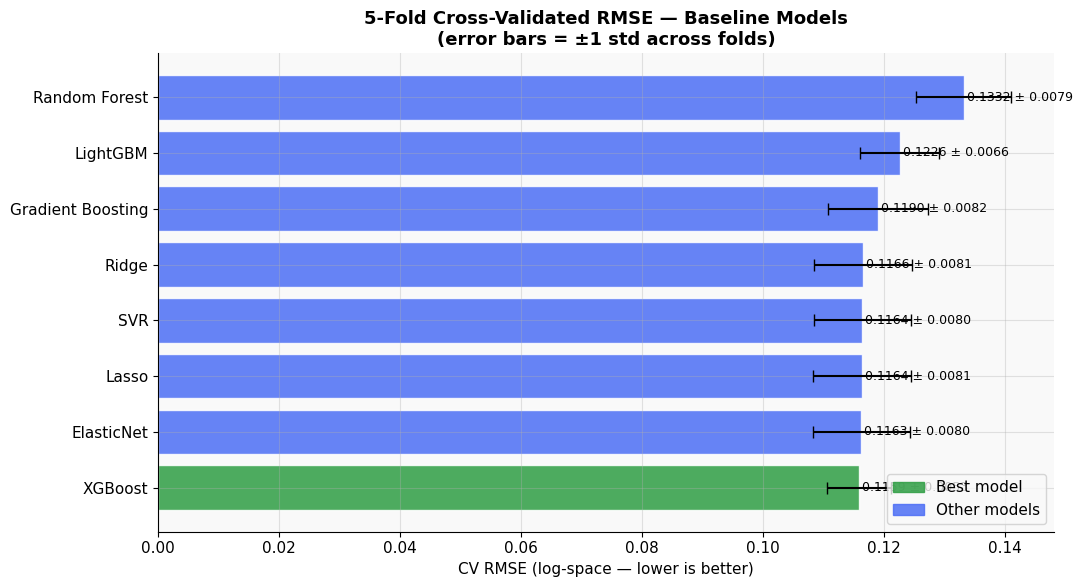

,Model,CV RMSE Mean,CV RMSE Std,CV R² (approx)
0,XGBoost,0.115916,0.005292,0.915843
1,ElasticNet,0.116285,0.008040,0.915307
2,Lasso,0.116361,0.008050,0.915196
3,SVR,0.116420,0.008029,0.915110
4,Ridge,0.116572,0.008064,0.914888
5,Gradient Boosting,0.119014,0.008203,0.911284
6,LightGBM,0.122598,0.006578,0.905861
7,Random Forest,0.133213,0.007873,0.888853


In [3]:
cv_scores = {}
for _, row in results_df.iterrows():
    cv_scores[row['Model']] = row['CV RMSE Mean']

fig, ax = plt.subplots(figsize=(11, 6))
models_sorted = results_df.sort_values('CV RMSE Mean')
bar_colors = [C[2] if i == 0 else C[0] for i in range(len(models_sorted))]
bars = ax.barh(models_sorted['Model'], models_sorted['CV RMSE Mean'],
               xerr=models_sorted['CV RMSE Std'], color=bar_colors,
               edgecolor='white', alpha=0.85, capsize=4)
for bar, (_, row) in zip(bars, models_sorted.iterrows()):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f"{row['CV RMSE Mean']:.4f} ± {row['CV RMSE Std']:.4f}",
            va='center', fontsize=9)
ax.set_xlabel('CV RMSE (log-space — lower is better)')
ax.set_title('5-Fold Cross-Validated RMSE — Baseline Models\n(error bars = ±1 std across folds)')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=C[2], alpha=0.85, label='Best model'),
    plt.Rectangle((0,0),1,1, color=C[0], alpha=0.85, label='Other models')
], loc='lower right')
plt.tight_layout()
plt.savefig('../plots/13_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
display(results_df)

## 2. Hyperparameter Tuning with Optuna

In [4]:
# Tune XGBoost — 50 trials (~5 mins)
print('Tuning XGBoost...')
best_xgb_params = tune_xgboost(X_train, y, n_trials=50)

Tuning XGBoost...


  0%|          | 0/50 [00:00<?, ?it/s]


Best XGBoost RMSE: 0.11443
Best params: {'n_estimators': 462, 'learning_rate': 0.036670075703117935, 'max_depth': 4, 'colsample_bytree': 0.5626665411911461, 'subsample': 0.8077848060274841, 'reg_alpha': 0.00010983942180634013, 'reg_lambda': 1.2327281066195424, 'min_child_weight': 2}


In [5]:
# Tune LightGBM — 50 trials
print('Tuning LightGBM...')
best_lgb_params = tune_lightgbm(X_train, y, n_trials=50)

Tuning LightGBM...


  0%|          | 0/50 [00:00<?, ?it/s]


Best LightGBM RMSE: 0.11749
Best params: {'n_estimators': 470, 'learning_rate': 0.041908117787742866, 'num_leaves': 40, 'max_depth': 4, 'colsample_bytree': 0.6689317100105427, 'subsample': 0.8777990562884614, 'reg_alpha': 0.00014186629343296314, 'reg_lambda': 0.000875620485755322, 'min_child_samples': 9}


In [6]:
# Compare tuned vs baseline
tuned_xgb = xgb.XGBRegressor(**{**best_xgb_params, 'random_state': 42, 'verbosity': 0})
tuned_lgb = lgb.LGBMRegressor(**{**best_lgb_params, 'random_state': 42, 'verbose': -1})

tuned_xgb_scores = cv_rmse(tuned_xgb, X_train, y)
tuned_lgb_scores = cv_rmse(tuned_lgb, X_train, y)

print(f'Tuned XGBoost:   {tuned_xgb_scores.mean():.5f} ± {tuned_xgb_scores.std():.5f}')
print(f'Tuned LightGBM:  {tuned_lgb_scores.mean():.5f} ± {tuned_lgb_scores.std():.5f}')
baseline_best = results_df['CV RMSE Mean'].min()
print(f'Baseline best:   {baseline_best:.5f}')
print(f'\nImprovement from tuning: {(baseline_best - min(tuned_xgb_scores.mean(), tuned_lgb_scores.mean())):.5f}')

Tuned XGBoost:   0.11443 ± 0.00604
Tuned LightGBM:  0.11749 ± 0.00642
Baseline best:   0.11592

Improvement from tuning: 0.00148


## 3. Stacking Ensemble

In [7]:
print('Building stacking ensemble (this takes a few minutes)...')
stack = build_stacking_ensemble(
    xgb_params=best_xgb_params,
    lgb_params=best_lgb_params
)
stack_scores = cv_rmse(stack, X_train, y)
print(f'Stacking CV RMSE: {stack_scores.mean():.5f} ± {stack_scores.std():.5f}')

Building stacking ensemble (this takes a few minutes)...
Stacking CV RMSE: 0.11375 ± 0.00811


## 4. Final Model Summary

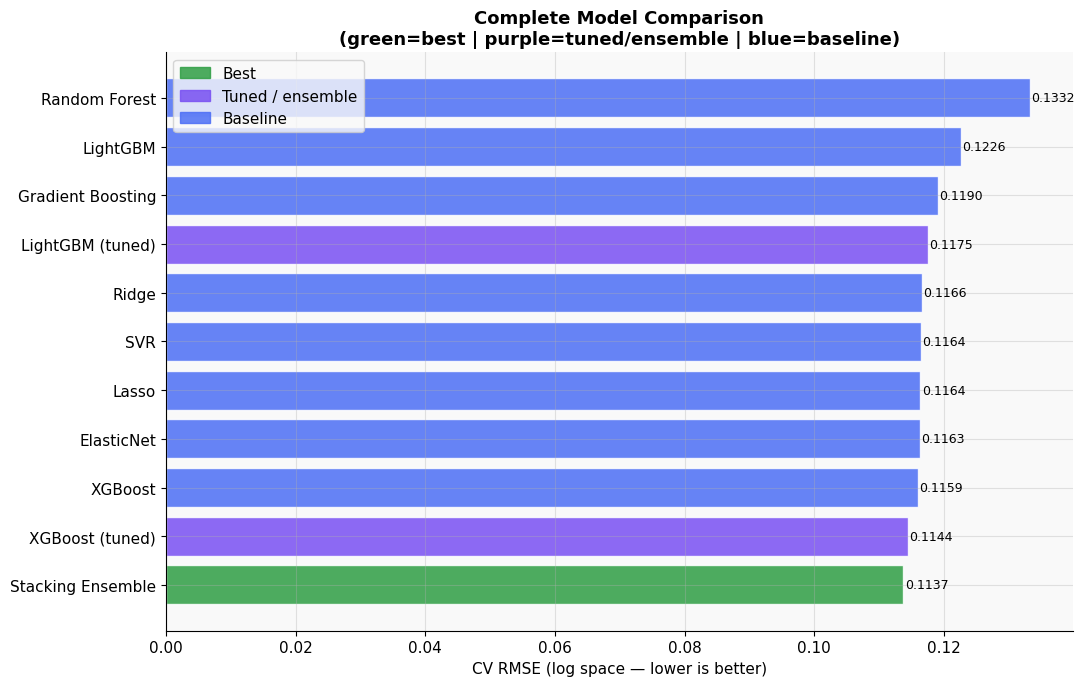

In [8]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import GradientBoostingRegressor

final_models = {
    **{row['Model']: row['CV RMSE Mean'] for _, row in results_df.iterrows()},
    'XGBoost (tuned)':   tuned_xgb_scores.mean(),
    'LightGBM (tuned)':  tuned_lgb_scores.mean(),
    'Stacking Ensemble': stack_scores.mean(),
}
final_df = pd.Series(final_models).sort_values()

fig, ax = plt.subplots(figsize=(11, 7))
colors_f = [C[2] if v == final_df.min() else
            C[4] if 'tuned' in k or 'Stack' in k else C[0]
            for k, v in final_df.items()]
ax.barh(final_df.index, final_df.values, color=colors_f, edgecolor='white', alpha=0.85)
for i, v in enumerate(final_df.values):
    ax.text(v + 0.0002, i, f'{v:.4f}', va='center', fontsize=9)
ax.set_xlabel('CV RMSE (log space — lower is better)')
ax.set_title('Complete Model Comparison\n(green=best | purple=tuned/ensemble | blue=baseline)')
ax.legend(handles=[
    plt.Rectangle((0,0),1,1, color=C[2], alpha=0.85, label='Best'),
    plt.Rectangle((0,0),1,1, color=C[4], alpha=0.85, label='Tuned / ensemble'),
    plt.Rectangle((0,0),1,1, color=C[0], alpha=0.85, label='Baseline'),
])
plt.tight_layout()
plt.savefig('../plots/14_final_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Learning Curves

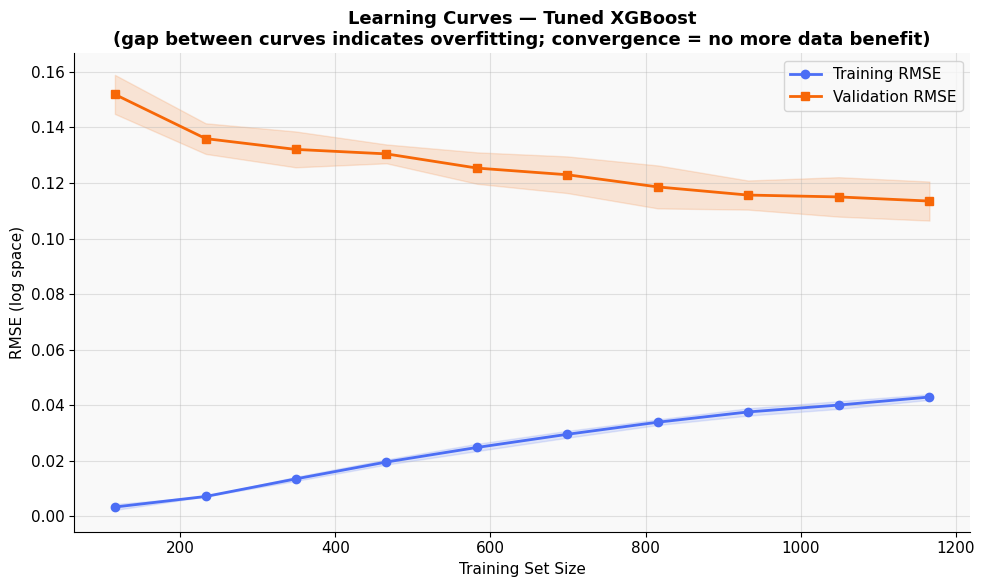

Final train/val RMSE gap: 0.0705
Interpretation: Moderate overfitting — consider more regularization


In [9]:
# Learning curves for best model — diagnose bias/variance
best_for_lc = tuned_xgb
train_sizes, train_scores, val_scores = learning_curve(
    best_for_lc, X_train, y,
    cv=5, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)
train_mean = -train_scores.mean(axis=1)
train_std  =  train_scores.std(axis=1)
val_mean   = -val_scores.mean(axis=1)
val_std    =  val_scores.std(axis=1)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(train_sizes, train_mean, color=C[0], lw=2, marker='o', label='Training RMSE')
ax.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.15, color=C[0])
ax.plot(train_sizes, val_mean, color=C[1], lw=2, marker='s', label='Validation RMSE')
ax.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.15, color=C[1])
ax.set_xlabel('Training Set Size')
ax.set_ylabel('RMSE (log space)')
ax.set_title('Learning Curves — Tuned XGBoost\n(gap between curves indicates overfitting; convergence = no more data benefit)')
ax.legend()
plt.tight_layout()
plt.savefig('../plots/15_learning_curves.png', dpi=150, bbox_inches='tight')
plt.show()

gap = val_mean[-1] - train_mean[-1]
print(f'Final train/val RMSE gap: {gap:.4f}')
print('Interpretation:', 'Moderate overfitting — consider more regularization' if gap > 0.02 else 'Good generalization')

## 6. Generate Predictions

In [10]:
# Fit all final models on full training data
from sklearn.linear_model import Ridge

ridge = Ridge(alpha=10)
gbm   = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=4, loss='huber', random_state=42)

for name, model in [('Ridge', ridge), ('GBM', gbm),
                    ('XGBoost (tuned)', tuned_xgb),
                    ('LightGBM (tuned)', tuned_lgb),
                    ('Stacking', stack)]:
    model.fit(X_train, y)
    print(f'Fitted {name}')

# Weighted blend — weights proportional to 1/RMSE
preds_log = {
    'ridge': ridge.predict(X_test),
    'gbm':   gbm.predict(X_test),
    'xgb':   tuned_xgb.predict(X_test),
    'lgbm':  tuned_lgb.predict(X_test),
    'stack': stack.predict(X_test),
}
preds = {k: np.expm1(v) for k, v in preds_log.items()}

# Weights: tuned tree models carry most weight
weights = {'ridge': 0.05, 'gbm': 0.10, 'xgb': 0.30, 'lgbm': 0.30, 'stack': 0.25}
final_preds = weighted_blend(preds, weights)

print(f'\nFinal blend prediction range: ${final_preds.min():,.0f} – ${final_preds.max():,.0f}')
print(f'Final blend median: ${np.median(final_preds):,.0f}')

Fitted Ridge
Fitted GBM
Fitted XGBoost (tuned)
Fitted LightGBM (tuned)
Fitted Stacking

Final blend prediction range: $45,421 – $650,504
Final blend median: $155,701


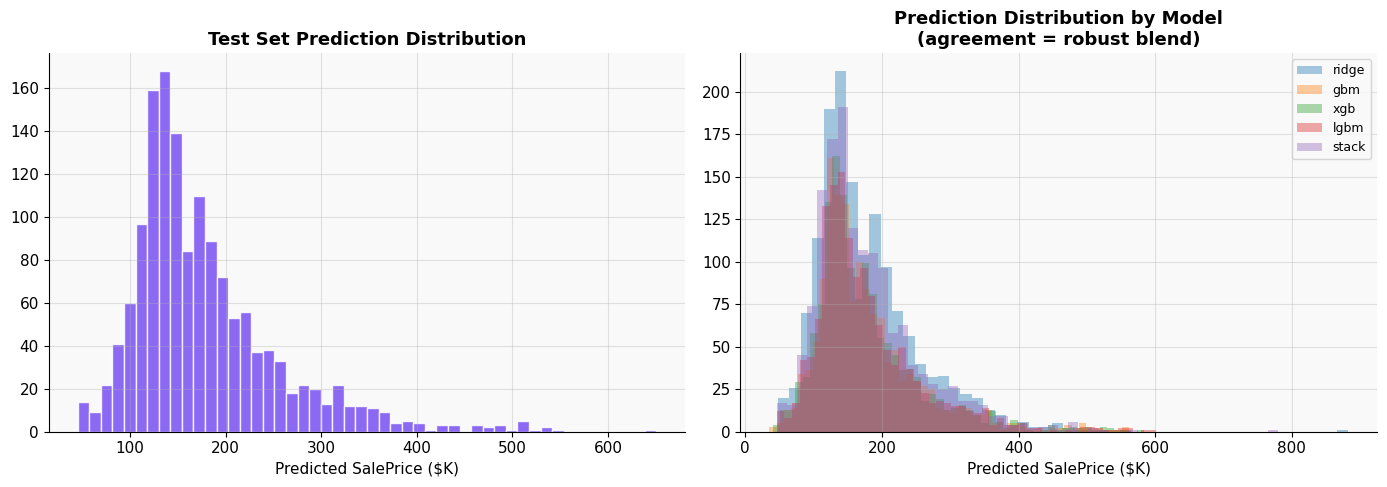

Saved submission.csv
Saved fitted models.


In [11]:
# Prediction distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(final_preds/1e3, bins=50, color=C[4], edgecolor='white', alpha=0.85)
axes[0].set_xlabel('Predicted SalePrice ($K)')
axes[0].set_title('Test Set Prediction Distribution')

# Prediction comparison across models
for name, pred in preds.items():
    axes[1].hist(pred/1e3, bins=50, alpha=0.4, label=name)
axes[1].set_xlabel('Predicted SalePrice ($K)')
axes[1].set_title('Prediction Distribution by Model\n(agreement = robust blend)')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig('../plots/16_prediction_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Save submission
submission = pd.DataFrame({'Id': test_ids, 'SalePrice': final_preds})
submission.to_csv('../data/submission.csv', index=False)
print('Saved submission.csv')

# Save fitted models for explainability notebook
with open('../data/processed/fitted_models.pkl', 'wb') as f:
    pickle.dump({'xgb': tuned_xgb, 'lgbm': tuned_lgb, 'stack': stack,
                 'ridge': ridge, 'gbm': gbm}, f)
print('Saved fitted models.')